# Petroleum Characterization — Milestone 19

Every calculation in this project so far has started the same way: name a compound, and the engine looks up its critical temperature, critical pressure and acentric factor. **Crude oil does not have those.** It is a mixture of many thousands of individual molecules that nobody has ever separated, let alone measured — and yet distillation columns have been designed for it for over a century.

How that is done is the subject of this notebook. The designer does not know *what* is in the barrel; what the assay tells them is **how much of it boils by what temperature** (a distillation curve) and **how dense it is** (a gravity). Milestone 19 turns those two measurements into a list of ordinary components the flash algorithms can use — slicing the boiling curve into narrow **pseudocomponents** and correlating each slice's properties from its boiling point and density alone.

Two numbers in, six out, a few hundred times over.

## Setup (optional)

The cell below is **commented out** — the notebook runs top-to-bottom against whatever `vle-thermo` is already in your kernel. Uncomment it to pull the newest released wheel from PyPI.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context from the research paper

This milestone sits *upstream* of everything the original thesis covered, and it is worth being clear about that rather than papering over it: **the research paper has no petroleum chapter.** Jackson & Mendible (1999) is about what to do once you have a component list. From [Chapter II §2.3 — Cubic Equations of State](../docs/en/research-paper/chapter-2-vle-theory.md#23-cubic-equations-of-state):

> The parameters $a$ and $b$ are obtained from the critical properties of the pure component...

That sentence quietly assumes the critical properties exist. For methane or benzene they do — somebody measured them. For "the 340–360 °C cut of Arab Light" they do not, and never will. Everything in this notebook exists to manufacture that missing input, so that the Chapter II machinery — the mixing rules of [§2.4](../docs/en/research-paper/chapter-2-vle-theory.md#24-mixing-rules), the flash algorithms of [Chapter III](../docs/en/research-paper/chapter-3-algorithms.md) — can run on a barrel of crude exactly as it runs on a two-component mixture.

The correlations themselves come from the petroleum-engineering literature rather than the thesis: Riazi & Daubert, Kesler & Lee, Twu, and the API *Technical Data Book*. Full citations are at the bottom.

## What Milestone 19 built

A new Rust module, `vle_thermo::petroleum`, surfaced in Python as **`vle.petroleum`**:

| piece | what it does |
|---|---|
| `distillation` | interconvert **ASTM D86 ↔ TBP ↔ D2887 (SimDist) ↔ EFV** curves |
| `cuts` | slice a TBP curve into $N$ pseudocomponents — by volume, by temperature, or at named product boundaries |
| `properties` | $T_b + SG \rightarrow M, T_c, P_c, \omega, V_c, Z_c$, in four correlation families |
| `cp` | ideal-gas $C_p^\circ$ for a fraction, as the polynomial `Component.cp_coeffs` already expects |
| `vapor_pressure` | Maxwell–Bonnell — turns a *vacuum* boiling point into a normal one |
| `gravity` | API gravity, the Watson factor, the five average boiling points |
| `assay` | the whole pipeline: `Assay` → `list[Component]` + mole fractions |

### Why four kinds of distillation curve

"How much of this oil boils below 200 °C" turns out to be four different questions, because the answer depends on the apparatus:

| basis | what it is | separation |
|---|---|---|
| **ASTM D86** | the cheap, fast lab standard — a single-stage flask | ~1 theoretical plate |
| **TBP** (D2892) | a real 15-plate column at 5:1 reflux | ~15 plates |
| **D2887 / SimDist** | gas chromatography, calibrated against n-alkanes | effectively perfect |
| **EFV** | one equilibrium flash — no fractionation at all | 0 plates |

Every property correlation downstream is written against **TBP**, because TBP is the one that approximates a list of molecular boiling points. Almost every assay you will be handed is D86 or D2887. So conversion is the first thing that happens, always.

### The Watson characterization factor

One number summarizing *what kind of hydrocarbon this is*, by comparing boiling point against density:

$$K_W = \frac{(T_b\ \text{in}\ ^\circ\text{R})^{1/3}}{SG}$$

Roughly **12.5–13** for paraffins (straight chains), **11–12** for naphthenes (saturated rings), **~10** for aromatics. It turns up as an input to the heat-capacity and vapor-pressure correlations, and it is the single most useful thing to know about a crude.

## Worked example, part 1 — converting a distillation curve

Before anything else, the validation. Riazi's *Characterization and Properties of Petroleum Fractions* (2005) works through a gas-oil D86 curve as **Example 3.3** and publishes the TBP curve it converts to, using API Procedure 3A1.1. That published answer is the test oracle: if the coefficient tables in this engine are right, we reproduce it.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from vle import petroleum
from vle.petroleum import Assay

# Riazi 2005, Example 3.3 -- a gas oil measured by ASTM D86.
x    = [0.0, 0.10, 0.30, 0.50, 0.70, 0.90]
d86C = [165.6, 173.7, 193.3, 206.7, 222.8, 242.8]          # degC
d86K = [t + 273.15 for t in d86C]

tbpK = petroleum.convert_curve(x, d86K, "d86", "tbp")
tbpC = [t - 273.15 for t in tbpK]

published = [133.5, 154.2, 189.2, 210.7, 232.9, 258.2]     # degC, Riazi Ex. 3.3

print(f"{'vol %':>7s}{'D86 / degC':>13s}{'TBP / degC':>13s}{'published':>12s}{'diff':>8s}")
for xi, a, b, p in zip(x, d86C, tbpC, published):
    print(f"{100*xi:7.0f}{a:13.1f}{b:13.1f}{p:12.1f}{b-p:8.2f}")

  vol %   D86 / degC   TBP / degC   published    diff
      0        165.6        133.5       133.5    0.03
     10        173.7        154.2       154.2   -0.01
     30        193.3        189.2       189.2   -0.04
     50        206.7        210.7       210.7   -0.00
     70        222.8        232.9       232.9    0.00
     90        242.8        258.2       258.2   -0.01


Agreement to a tenth of a degree across the whole curve.

Notice what the conversion *did*: the TBP curve starts **32 °C lower** and ends **15 °C higher** than the D86 curve of the same oil. That spread is the physical content of the whole exercise — a 15-plate column separates the light ends from the heavy ends far better than a single-stage flask, so it reports a wider boiling range for identical material. Using a D86 curve where a TBP curve belongs would compress the barrel and give you pseudocomponents that are all too similar to each other.

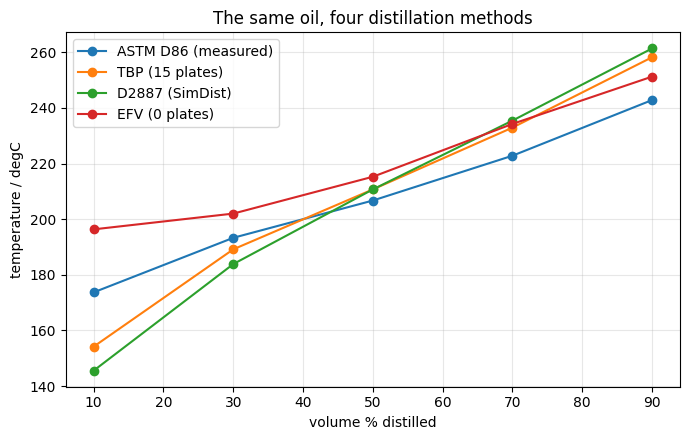

ASTM D86 (measured)    boiling span   69.1 K
TBP (15 plates)        boiling span  104.0 K
D2887 (SimDist)        boiling span  115.8 K
EFV (0 plates)         boiling span   54.9 K


In [3]:
# Assertion cell: a regression here means a coefficient table changed.
for got, want in zip(tbpC, published):
    assert abs(got - want) < 0.15, f'TBP {got:.2f} vs published {want}'

# The four bases on one plot, over 10-90 % -- see the note below on why the
# initial point is dropped for the EFV comparison.
sg_bulk = 0.85
x9, d86K9 = x[1:], d86K[1:]
bases = {
    'ASTM D86 (measured)': d86K9,
    'TBP (15 plates)':     petroleum.convert_curve(x9, d86K9, 'd86', 'tbp'),
    'D2887 (SimDist)':     petroleum.convert_curve(x9, d86K9, 'd86', 'd2887'),
    'EFV (0 plates)':      petroleum.convert_curve(x9, d86K9, 'd86', 'efv', sg=sg_bulk),
}

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, t in bases.items():
    ax.plot(np.array(x9) * 100, np.array(t) - 273.15, 'o-', label=name)
ax.set_xlabel('volume % distilled')
ax.set_ylabel('temperature / degC')
ax.set_title('The same oil, four distillation methods')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

spans = {k: v[-1] - v[0] for k, v in bases.items()}
for k, v in spans.items():
    print(f'{k:22s} boiling span {v:6.1f} K')
assert spans['TBP (15 plates)'] > spans['ASTM D86 (measured)'] > spans['EFV (0 plates)']

The ordering of those spans is the whole story in one line: **more theoretical plates, wider apparent boiling range.** The EFV curve — a single equilibrium flash, no fractionation whatsoever — is the flattest of the four, because a flash separates almost nothing.

> **Why the 0 % point was dropped.** Edmister–Okamoto is a *point-wise* correlation: each decile has its own independently fitted `(a, b, c)` row, and nothing in the fitting forced the rows to agree at their boundaries. The 0–10 % row and the 10–30 % row genuinely cross, so on any D86 curve narrower than roughly 250 K the converted EFV initial point lands *above* the 10 % point. Rather than hand back a decreasing distillation curve, the engine rejects it — try `petroleum.convert_curve(x, d86K, 'd86', 'efv', sg=0.85)` on the full curve and read the error. Converting from 10 % up is the standard workaround, and no loss: a D86 initial boiling point is the least reproducible number on the whole report.

## Worked example, part 2 — a crude assay into pseudocomponents

Now the real thing. A light sweet crude: a TBP curve running from 310 K to 790 K, and a bulk gravity of **35 °API**. That is *all* the input.

The one modelling decision worth understanding is how a single bulk gravity becomes a gravity for each cut. `Assay` assumes the barrel is chemically uniform — one Watson factor throughout — and then picks that factor so the cuts **blend back to the bulk gravity exactly**. So the characterization conserves volume and mass rather than approximately conserving them. (If your lab reported a gravity *curve*, pass it instead as `sg_fractions` / `sg_values`; it is strictly better information.)

In [4]:
assay = Assay(
    fractions   = [0.0, 0.10, 0.30, 0.50, 0.70, 0.90, 0.95],
    temperatures= [310.0, 380.0, 460.0, 540.0, 620.0, 730.0, 790.0],   # K, TBP
    basis       = 'tbp',
    api_gravity = 35.0,
)
print(assay)
print(f'Watson K of the whole barrel: {assay.watson_k():.2f}  '
      f'({"paraffinic" if assay.watson_k() > 12 else "naphthenic/aromatic"})')

cuts = assay.cuts(n=10)

hdr = f"{'cut':<6}{'Tb/K':>8}{'SG':>8}{'API':>7}{'M':>8}{'Tc/K':>8}{'Pc/kPa':>9}{'omega':>8}{'vol%':>7}{'mol%':>7}"
print()
print(hdr); print('-' * len(hdr))
for c in cuts:
    print(f"{c['name']:<6}{c['tb']:8.1f}{c['sg']:8.4f}{c['api_gravity']:7.1f}"
          f"{c['mw']:8.1f}{c['tc']:8.1f}{c['pc']:9.1f}{c['omega']:8.3f}"
          f"{100*c['fraction']:7.2f}{100*c['mole_fraction']:7.2f}")

Assay(TBP curve, 7 points, bulk_sg=0.8498498498498499, method=ApiRiaziDaubert1987)
Watson K of the whole barrel: 11.40  (naphthenic/aromatic)

cut       Tb/K      SG    API       M    Tc/K   Pc/kPa   omega   vol%   mol%
----------------------------------------------------------------------------
PC-1     343.2  0.7376   60.3    86.2   526.4   3653.0   0.241  10.00  18.18
PC-2     397.0  0.7742   51.3   112.2   587.1   3009.4   0.312  10.00  14.66
PC-3     435.0  0.7982   45.8   133.2   628.3   2644.9   0.364  10.00  12.73
PC-4     473.0  0.8208   40.9   156.7   668.4   2340.2   0.417  10.00  11.13
PC-5     511.0  0.8422   36.5   182.9   707.4   2083.8   0.472  10.00   9.78
PC-6     549.0  0.8626   32.5   212.2   745.5   1867.1   0.529  10.00   8.63
PC-7     587.0  0.8821   28.9   245.1   782.8   1683.0   0.588  10.00   7.64
PC-8     627.8  0.9021   25.4   285.0   822.2   1515.1   0.654  10.00   6.72
PC-9     679.1  0.9260   21.3   342.6   870.8   1340.0   0.742  10.00   5.74
PC-10    7

Read down the table and every trend is the one physical intuition demands: heavier cuts boil higher, are denser, weigh more per molecule, have higher critical temperatures, **lower** critical pressures, and larger acentric factors. Note too that the *volume* percentages are all equal (we asked for equal-volume cuts) while the *mole* percentages are not — the light cuts contribute far more molecules per barrel than the heavy ones, which is exactly why a crude column's overhead is so much larger than its bottoms in molar terms.

In [5]:
# Assertion cell: the invariants that make this a valid characterization.
assert abs(sum(c['fraction'] for c in cuts) - 1.0) < 1e-12
assert abs(sum(c['mole_fraction'] for c in cuts) - 1.0) < 1e-12

# Gravity closure: the cuts must blend back to 35 degAPI exactly.
blended = sum(c['fraction'] * c['sg'] for c in cuts)
assert abs(blended - petroleum.sg_from_api(35.0)) < 1e-12, blended
print(f'blended gravity = {petroleum.api_from_sg(blended):.6f} degAPI  (input: 35.0)')

# Monotonicity, cut by cut.
for lo, hi in zip(cuts, cuts[1:]):
    assert hi['tb'] > lo['tb'] and hi['mw'] > lo['mw']
    assert hi['tc'] > lo['tc'] and hi['pc'] < lo['pc'] and hi['omega'] > lo['omega']
print('all monotonicity checks passed')

blended gravity = 35.000000 degAPI  (input: 35.0)
all monotonicity checks passed


### The property trends, drawn

Four correlation families ship in this engine, and they disagree — sometimes usefully so. Plotting them against each other is the honest way to see how much of a characterization is *choice* rather than measurement.

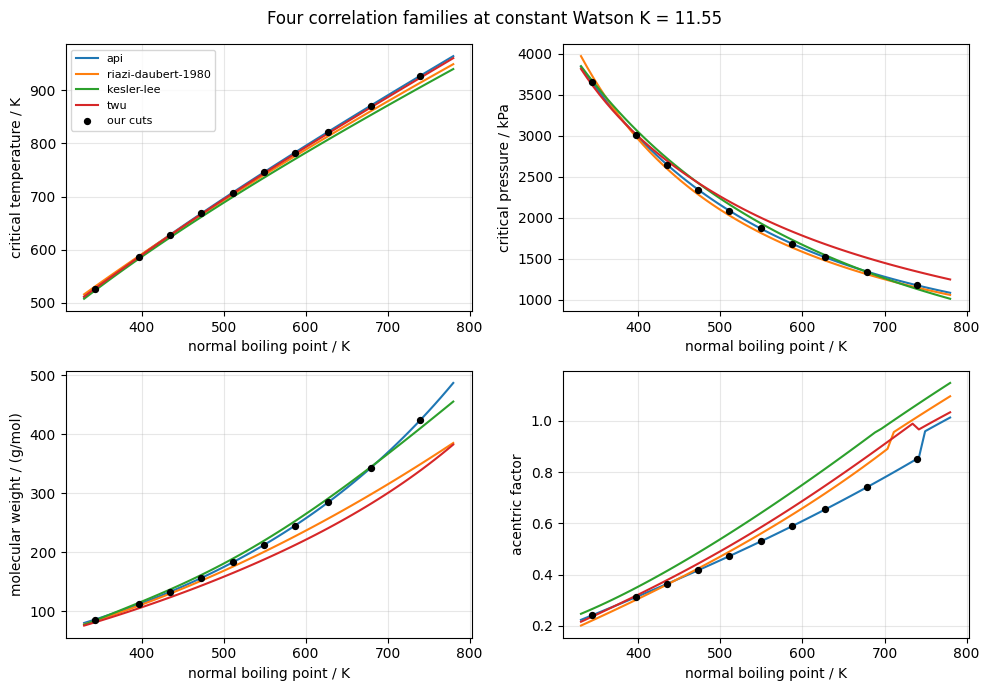

In [6]:
# Sweep boiling point at the assay's own Watson K, exactly as the assay does:
# SG = (1.8 Tb)^(1/3) / Kw.
KW = cuts[0]['watson_k']
tb_grid = np.linspace(330.0, 780.0, 60)
sg_grid = np.array([(1.8 * t) ** (1/3) / KW for t in tb_grid])

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
panels = [('tc', 'critical temperature / K'), ('pc', 'critical pressure / kPa'),
          ('mw', 'molecular weight / (g/mol)'), ('omega', 'acentric factor')]

for ax, (key, label) in zip(axes.ravel(), panels):
    for method in petroleum.PROPERTY_METHODS:
        vals = []
        for t, s in zip(tb_grid, sg_grid):
            try:
                vals.append(petroleum.estimate(t, s, method=method)[key])
            except Exception:
                vals.append(np.nan)
        ax.plot(tb_grid, vals, label=method)
    ax.scatter([c['tb'] for c in cuts], [c[key] for c in cuts],
               c='k', zorder=5, s=18, label='our cuts')
    ax.set_xlabel('normal boiling point / K'); ax.set_ylabel(label)
    ax.grid(alpha=0.3)
axes[0, 0].legend(fontsize=8)
fig.suptitle(f'Four correlation families at constant Watson K = {KW:.2f}')
plt.tight_layout(); plt.show()

The families agree closely on **critical temperature** — within about 1 % across the whole range — and diverge much more on **critical pressure** and **molecular weight**, where 5–10 % spread is normal. That ranking is not an accident: $T_c$ correlates tightly with boiling point (both measure how hard the molecules are to pull apart), whereas $P_c$ and $M$ depend on molecular *shape*, which two bulk numbers cannot fully capture.

Twu (1984) is the interesting one. It is built as a **perturbation about the n-alkane of the same boiling point**: find the paraffin that boils here, take its properties from a high-accuracy fit, then correct for how far the real cut's density sits from that paraffin's. So it is near-exact on paraffinic material by construction — and measurably worse on aromatics, where the perturbation is large. Pick it for a paraffinic crude, not for an aromatic one.

### Cutting at product boundaries

Equal-volume slicing is what you want for feeding a column model. But if you are trying to match a refinery's actual **product yields**, you want to cut where the tower cuts — at the draw specifications.

In [7]:
products = ['naphtha', 'kerosene', 'diesel', 'AGO', 'residue']
prod_cuts = assay.cuts(boundaries=['175 degC', '235 degC', '340 degC', '370 degC'])

print(f"{'product':<10}{'range / degC':>20}{'vol %':>9}{'API':>8}{'M':>8}")
for name, c in zip(products, prod_cuts):
    rng = f"{c['t_lower']-273.15:.0f} - {c['t_upper']-273.15:.0f}"
    print(f'{name:<10}{rng:>20}{100*c["fraction"]:9.1f}{c["api_gravity"]:8.1f}{c["mw"]:8.1f}')

assert abs(sum(c['fraction'] for c in prod_cuts) - 1.0) < 1e-12
# Products get heavier and denser (lower API) down the tower.
assert all(b['api_gravity'] < a['api_gravity'] for a, b in zip(prod_cuts, prod_cuts[1:]))

product           range / degC    vol %     API       M
naphtha               37 - 175     28.5    52.7   107.9
kerosene             175 - 235     15.8    40.3   160.1
diesel               235 - 340     27.6    31.5   222.0
AGO                  340 - 370      6.2    25.5   284.5
residue              370 - 517     21.9    19.5   374.5


Those five rows are a crude-tower yield table. The API gravities fall monotonically down the column — the light naphtha overhead is the most valuable and least dense stream, the residue at the bottom the heaviest — which is the economic shape of the whole refinery in one column of numbers.

## Worked example, part 3 — flashing the assay

Here is the payoff. The pseudocomponents are **ordinary `Component` objects**: nothing downstream knows or cares that their properties were correlated rather than measured. So they go straight into a `System` and straight into the flash algorithms from Milestone 9.

In [8]:
system, z = assay.to_system(n=30, eos='PR')
print(system)

T, P = 500.0, 200.0                       # K, kPa
res = system.flash_pt(T, P, z)

print(f'\nflash at {T} K, {P} kPa')
print(f'  vapor fraction beta = {res.beta:.4f}')
print(f'  K-values span       = {min(res.k):.2e} .. {max(res.k):.2f}')

# Component mass balance: z = beta*y + (1-beta)*x, for all 30 of them.
err = max(abs(res.beta*res.y[i] + (1-res.beta)*res.x[i] - z[i]) for i in range(len(z)))
print(f'  max mass-balance error = {err:.2e}')
assert res.two_phase and 0.0 < res.beta < 1.0
assert err < 1e-12

System(['PC-1', 'PC-2', 'PC-3', 'PC-4', 'PC-5', 'PC-6', 'PC-7', 'PC-8', 'PC-9', 'PC-10', 'PC-11', 'PC-12', 'PC-13', 'PC-14', 'PC-15', 'PC-16', 'PC-17', 'PC-18', 'PC-19', 'PC-20', 'PC-21', 'PC-22', 'PC-23', 'PC-24', 'PC-25', 'PC-26', 'PC-27', 'PC-28', 'PC-29', 'PC-30'])

flash at 500.0 K, 200.0 kPa
  vapor fraction beta = 0.4260
  K-values span       = 2.08e-04 .. 12.49
  max mass-balance error = 6.94e-18


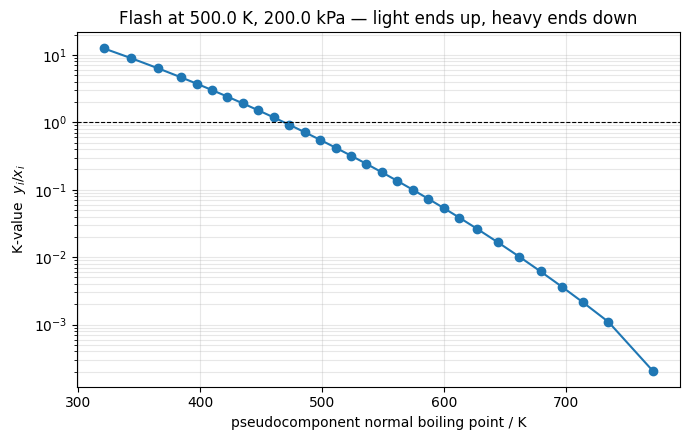

K = 1 at a normal boiling point of about 469 K (196 degC)


In [9]:
# Where does each pseudocomponent go?
tb = np.array([c.tb for c in system.components])
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(tb, res.k, 'o-', color='C0')
ax.axhline(1.0, color='k', lw=0.8, ls='--')
ax.set_xlabel('pseudocomponent normal boiling point / K')
ax.set_ylabel('K-value  $y_i/x_i$')
ax.set_title(f'Flash at {T} K, {P} kPa — light ends up, heavy ends down')
ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

# K = 1 is the dividing line: everything boiling below it goes overhead.
crossover = np.interp(0.0, np.log(res.k)[::-1], tb[::-1])
print(f'K = 1 at a normal boiling point of about {crossover:.0f} K '
      f'({crossover-273.15:.0f} degC)')

The K-value curve falls smoothly through $K = 1$, and the boiling point where it crosses is the flash's natural cut point: everything lighter goes overhead, everything heavier stays in the liquid. This is a *flash drum*, not a column, so the separation is soft — but it is the same calculation a crude tower performs on every one of its trays, and running it on 30 pseudocomponents instead of 3 is what makes the answer resemble a real barrel.

## Maxwell–Bonnell, and why vacuum distillation exists

One more piece, because a real assay depends on it. Heavy petroleum **cracks before it boils**: a vacuum gas oil that would boil around 500 °C at atmospheric pressure decomposes somewhere above 350 °C. So its distillation has to be run under vacuum — and then the measured temperatures are not boiling points at all, they are boiling points *at 10 mmHg*.

Maxwell & Bonnell's correlation converts between them. It is what makes ASTM D1160 and D2892 vacuum data usable by everything above.

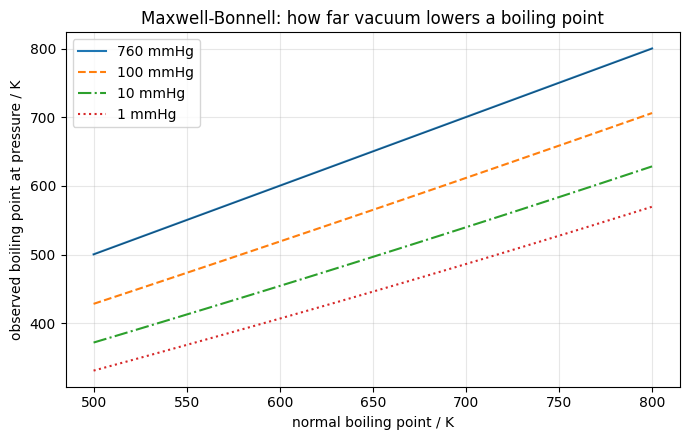

An 800 K cut boils at 628 K (355 degC) under 10 mmHg
-> safely below the ~377 degC cracking threshold


In [10]:
tb_normal = np.linspace(500.0, 800.0, 40)
fig, ax = plt.subplots(figsize=(7, 4.5))
for p_mmhg, style in [(760, '-'), (100, '--'), (10, '-.'), (1, ':')]:
    t = [petroleum.boiling_point_at_pressure(x, f'{p_mmhg} mmHg', 11.8) for x in tb_normal]
    ax.plot(tb_normal, t, style, label=f'{p_mmhg} mmHg')
ax.plot(tb_normal, tb_normal, color='k', lw=0.6, alpha=0.4)
ax.set_xlabel('normal boiling point / K')
ax.set_ylabel('observed boiling point at pressure / K')
ax.set_title('Maxwell-Bonnell: how far vacuum lowers a boiling point')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

CRACKING_K = 650.0     # ~375 degC, where heavy oil starts to decompose
t10 = petroleum.boiling_point_at_pressure(800.0, '10 mmHg', 11.8)
print(f'An 800 K cut boils at {t10:.0f} K ({t10-273.15:.0f} degC) under 10 mmHg')
print(f'-> {"safely below" if t10 < CRACKING_K else "ABOVE"} the ~{CRACKING_K-273.15:.0f} degC cracking threshold')
assert t10 < CRACKING_K

An 800 K (527 °C) cut — utterly undistillable at atmospheric pressure — boils comfortably below the cracking threshold at 10 mmHg. That single fact is why every refinery has a vacuum tower.

## Exercises

### Exercise 1 — how much does the correlation choice matter?

The four property families disagree, and we plotted that. Now quantify it where it counts: characterize the same assay with each family, flash all four at 500 K and 200 kPa, and compare the vapor fractions.

Is the spread in $\beta$ small enough to ignore, or is the choice of correlation a first-order modelling decision?

In [11]:
# TODO: for each method in petroleum.PROPERTY_METHODS,
#   1. build an Assay with method=<that method> (same curve and gravity)
#   2. to_system(n=20, eos='PR')
#   3. flash at 500 K, 200 kPa
#   4. record beta, and the mixture's average Tc
# Then print a table and comment on the spread.

for method in petroleum.PROPERTY_METHODS:
    ...   # your code here

<details>
<summary><b>Solution</b></summary>

```python
print(f"{'method':<22}{'beta':>8}{'mean Tc / K':>14}")
betas = {}
for method in petroleum.PROPERTY_METHODS:
    a = Assay(fractions=[0.0, 0.10, 0.30, 0.50, 0.70, 0.90, 0.95],
              temperatures=[310.0, 380.0, 460.0, 540.0, 620.0, 730.0, 790.0],
              basis='tbp', api_gravity=35.0, method=method)
    s, zz = a.to_system(n=20, eos='PR')
    r = s.flash_pt(500.0, 200.0, zz)
    mean_tc = sum(zi * c.tc for zi, c in zip(zz, s.components))
    betas[method] = r.beta
    print(f'{method:<22}{r.beta:8.4f}{mean_tc:14.1f}')

spread = max(betas.values()) - min(betas.values())
print(f'\nspread in beta: {spread:.4f} '
      f'({100*spread/np.mean(list(betas.values())):.1f}% of the mean)')
```

The vapor fractions typically land within a few percent of each other — the correlations agree far better on the *ordering* of the cuts than on their absolute properties, and a flash mostly cares about ordering. But the spread is not negligible either: it is comfortably larger than the convergence tolerance, so quoting $\beta$ to four decimals from any single correlation would be false precision. The honest reporting is a range.

</details>

### Exercise 2 — a heavy, aromatic crude

The assay above is a light sweet crude at 35 °API. Real heavy crudes are much denser and much more aromatic.

Characterize a **20 °API** barrel over the same boiling curve. What happens to the Watson factor, and what does that imply about the ideal-gas heat capacity? (Try `assay.cuts(n=10)` and read the error message carefully if it fails.)

In [12]:
# TODO:
#   1. build the same curve at api_gravity=20.0
#   2. print its Watson K and compare to the 35 degAPI barrel
#   3. characterize it into 10 cuts -- what happens?
#   4. use petroleum.ideal_gas_cp to compare Cp at Kw = 10 vs Kw = 12.7 at 600 K

heavy = ...   # your code here

<details>
<summary><b>Solution</b></summary>

```python
heavy = Assay(fractions=[0.0, 0.10, 0.30, 0.50, 0.70, 0.90, 0.95],
              temperatures=[310.0, 380.0, 460.0, 540.0, 620.0, 730.0, 790.0],
              basis='tbp', api_gravity=20.0)

print(f'35 degAPI barrel: Kw = {assay.watson_k():.2f}')
print(f'20 degAPI barrel: Kw = {heavy.watson_k():.2f}')

heavy_cuts = heavy.cuts(n=10)
print(f'characterized {len(heavy_cuts)} cuts, '
      f'Kw per cut = {heavy_cuts[0]["watson_k"]:.2f}')

for kw in (10.0, 11.5, 12.7):
    cp = petroleum.ideal_gas_cp(kw, 600.0)
    print(f'Kw = {kw:5.1f}:  Cp = {cp:.3f} kJ/(kg K)')
```

The heavier barrel's Watson factor drops from about 11.4 to about 10.4 — the same boiling range at a much higher density means much more aromatic material. The characterization still succeeds, because 10.4 is inside the correlation's fitted window.

Push it further, though (say 10 °API), and `cuts()` raises a `ValueError` naming the offending cut and the Watson-K window it fell outside. That is deliberate: silently extrapolating a heat-capacity correlation is how a column energy balance ends up quietly wrong, so the engine refuses instead.

The $C_p$ comparison shows why $K_W$ is the right correlating variable: per kilogram, a hydrogen-rich paraffin holds substantially more heat than a hydrogen-poor aromatic, because ideal-gas heat capacity is essentially a count of vibrational modes per unit mass.

</details>

### Exercise 3 — reproduce a published SimDist conversion

Riazi's **Example 3.4** converts a D2887 (SimDist) curve to TBP by API Procedure 3A3.1:

| vol % | 10 | 30 | 50 | 70 | 90 |
|---|---|---|---|---|---|
| **SimDist / °C** | 151.7 | 162.2 | 168.9 | 173.3 | 181.7 |
| **published TBP / °C** | 164.3 | 166.9 | 168.9 | 170.9 | 176.8 |

Reproduce it, and explain why the 50 % point is unchanged while the ends move *inward*.

In [13]:
# TODO: use petroleum.convert_curve to go from 'd2887' to 'tbp',
# then compare against the published values above.

x_sd  = [0.1, 0.3, 0.5, 0.7, 0.9]
sd_C  = [151.7, 162.2, 168.9, 173.3, 181.7]
...   # your code here

Ellipsis

<details>
<summary><b>Solution</b></summary>

```python
x_sd = [0.1, 0.3, 0.5, 0.7, 0.9]
sd_C = [151.7, 162.2, 168.9, 173.3, 181.7]
published = [164.3, 166.9, 168.9, 170.9, 176.8]

tbp = petroleum.convert_curve(x_sd, [t + 273.15 for t in sd_C], 'd2887', 'tbp')
tbp_C = [t - 273.15 for t in tbp]

print(f"{'vol %':>7}{'SimDist':>10}{'TBP':>10}{'published':>12}")
for xi, a, b, p in zip(x_sd, sd_C, tbp_C, published):
    print(f'{100*xi:7.0f}{a:10.1f}{b:10.1f}{p:12.1f}')
    assert abs(b - p) < 0.15
```

The 50 % point is unchanged because API Procedure 3A3.1 **takes the two medians to be equal** — gas chromatography separates so well that its median already *is* the true boiling median. Only the differences between adjacent points need converting.

The ends move inward because a chromatogram over-resolves relative to a real column: it reports a wider spread than a 15-plate distillation would, so converting to TBP narrows it. This is the opposite of the D86 → TBP direction, where the poorly-separating flask under-reports the spread and the conversion widens it. Both corrections are pushing the measurement toward the same physical truth from opposite sides.

</details>

## References

**Research paper**
- [Chapter II — VLE Theory](../docs/en/research-paper/chapter-2-vle-theory.md) — the cubic-EOS and mixing-rule framework the pseudocomponents feed
- [Chapter III — Algorithms](../docs/en/research-paper/chapter-3-algorithms.md) — the flash algorithms used at the end of this notebook

**Learning guide**
- [`docs/en/petroleum/README.md`](../docs/en/petroleum/README.md) — the domain from first principles, every correlation written out with its published units, the validation provenance, and a full function reference

**Plan documents**
- [`PETROLEUM_PSEUDOCOMPONENT_PLAN.md`](../docs/plans/engine/PETROLEUM_PSEUDOCOMPONENT_PLAN.md) §2 (U1, U2) — the design record for this milestone
- [`MODERNIZATION_PLAN.md`](../docs/plans/MODERNIZATION_PLAN.md) — Phase 26

**Correlations** (full citations in the `vle_thermo::petroleum` module docs)
- Riazi, M. R. *Characterization and Properties of Petroleum Fractions*; ASTM MNL50, **2005** — the standard text; Examples 3.3 and 3.4 are the oracles used above
- Riazi, M. R.; Daubert, T. E. *Ind. Eng. Chem. Res.* **1987**, *26*, 755 — the default critical-property correlation
- Daubert, T. E. *Hydrocarbon Process.* **1994**, *73* (9), 75 — API Procedures 3A1.1, 3A3.1, 3A3.2
- Kesler, M. G.; Lee, B. I. *Hydrocarbon Process.* **1976**, *55* (3), 153 — critical properties and ideal-gas $C_p^\circ$
- Twu, C. H. *Fluid Phase Equilib.* **1984**, *16*, 137 — the n-alkane perturbation method
- Edmister, W. C.; Okamoto, K. K. *Pet. Refiner* **1959**, *38* (9), 271 — EFV conversions
- Maxwell, J. B.; Bonnell, L. S., Esso Research **1955** — API Procedure 5A1.19

**Next**
- Milestone 20 — refinery thermodynamics: free-water/three-phase handling, Grayson–Streed and BK10 K-values, Lee–Kesler enthalpy departure, Peneloux volume translation